In [ ]:
import pandas as pd

df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df.columns = df.columns.str.strip()
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df['streams'] = df['streams'].fillna(0)

print("Total rows (no removal):", len(df))

bins = [0, 200_000_000, 400_000_000, 600_000_000,
        800_000_000, 1_000_000_000, 1_500_000_000, float('inf')]

labels = ['0-200M','200M-400M','400M-600M','600M-800M',
          '800M-1B','1B-1.5B','1.5B+']

df['class_interval'] = pd.cut(df['streams'], bins=bins, labels=labels, include_lowest=True)


freq = df['class_interval'].value_counts().sort_index()
cum_freq = freq.cumsum()
rel_freq = (freq / len(df)) * 100
cum_rel_freq = rel_freq.cumsum()

table = pd.DataFrame({
    'Class Interval': freq.index,
    'Frequency (f)': freq.values,
    'Relative Freq (%)': rel_freq.round(2).values,
    'Cumulative Freq': cum_freq.values,
    'Cumulative Rel Freq (%)': cum_rel_freq.round(2).values
})

total = pd.DataFrame({
    'Class Interval': ['TOTAL'],
    'Frequency (f)': [freq.sum()],
    'Relative Freq (%)': [round(rel_freq.sum(), 2)],
    'Cumulative Freq': [cum_freq.iloc[-1]],
    'Cumulative Rel Freq (%)': [round(cum_rel_freq.iloc[-1], 2)]
})

table = pd.concat([table, total], ignore_index=True)


print("\nFrequency Table:\n")
print(table.to_string(index=False))

print("\nCheck Total Rows:", len(df))
print("Check Frequency Sum:", freq.sum())

Total rows (no removal): 953

Frequency Table:

Class Interval  Frequency (f)  Relative Freq (%)  Cumulative Freq  Cumulative Rel Freq (%)
        0-200M            356              37.36              356                    37.36
     200M-400M            227              23.82              583                    61.18
     400M-600M            103              10.81              686                    71.98
     600M-800M             71               7.45              757                    79.43
       800M-1B             44               4.62              801                    84.05
       1B-1.5B             82               8.60              883                    92.65
         1.5B+             70               7.35              953                   100.00
         TOTAL            953             100.00              953                   100.00

Check Total Rows: 953
Check Frequency Sum: 953


In [1]:
import pandas as pd

df = pd.read_csv("spotify-2023.csv", encoding='latin1')

df.columns = df.columns.str.strip()

print("----- DATASET INFO -----")
print("Shape (rows, columns):", df.shape)
print("Total rows:", len(df))
print("Total columns:", len(df.columns))

print("\n----- COLUMN NAMES -----")
print(df.columns)

if 'streams' in df.columns:
    print("\n'streams' column exists ")
else:
    print("\n'streams' column NOT found ")

df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

print("\n----- STREAMS COLUMN INFO -----")
print("Data type:", df['streams'].dtype)
print("Total values:", len(df['streams']))
print("Non-null values:", df['streams'].count())
print("Missing values:", df['streams'].isnull().sum())

print("\n----- STREAMS STATISTICS -----")
print("Minimum:", df['streams'].min())
print("Maximum:", df['streams'].max())
print("Mean:", df['streams'].mean())
print("Median:", df['streams'].median())
print("Mode:", df['streams'].mode()[0])
print("Standard Deviation:", df['streams'].std())

print("\n----- FINAL CHECK -----")
print("Rows after conversion (no drop):", len(df))

----- DATASET INFO -----
Shape (rows, columns): (953, 24)
Total rows: 953
Total columns: 24

----- COLUMN NAMES -----
Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='str')

'streams' column exists 

----- STREAMS COLUMN INFO -----
Data type: float64
Total values: 953
Non-null values: 952
Missing values: 1

----- STREAMS STATISTICS -----
Minimum: 2762.0
Maximum: 3703895074.0
Mean: 514137424.93907565
Median: 290530915.0
Mode: 156338624.0
Standard Deviation: 566856949.038883

----- FINAL CHECK -----
Rows after conversion (no drop): 953


In [3]:
import pandas as pd

df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df.columns = df.columns.str.strip()

# Convert to numeric (invalid → NaN)
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

print("----- DATA RANGE -----")
print("Minimum streams:", df['streams'].min())
print("Maximum streams:", df['streams'].max())

print("\n----- QUARTILES -----")
print(df['streams'].describe())

# Auto bins (just for checking distribution)
df['auto_bins'] = pd.cut(df['streams'], bins=7)

print("\n----- AUTO INTERVALS -----")
print(df['auto_bins'].value_counts().sort_index())

# Your manual class intervals
bins = [0, 200_000_000, 400_000_000, 600_000_000,
        800_000_000, 1_000_000_000, 1_500_000_000, float('inf')]

labels = ['0-200M','200M-400M','400M-600M','600M-800M',
          '800M-1B','1B-1.5B','1.5B+']

df['class_interval'] = pd.cut(df['streams'], bins=bins, labels=labels, include_lowest=True)

freq = df['class_interval'].value_counts().sort_index()

print("\n----- YOUR INTERVAL CHECK -----")
print(freq)

print("\nTotal rows:", len(df))
print("Sum of frequencies:", freq.sum())


----- DATA RANGE -----
Minimum streams: 2762.0
Maximum streams: 3703895074.0

----- QUARTILES -----
count    9.520000e+02
mean     5.141374e+08
std      5.668569e+08
min      2.762000e+03
25%      1.416362e+08
50%      2.905309e+08
75%      6.738690e+08
max      3.703895e+09
Name: streams, dtype: float64

----- AUTO INTERVALS -----
auto_bins
(-3701130.312, 529130235.143]       656
(529130235.143, 1058257708.286]     152
(1058257708.286, 1587385181.429]     77
(1587385181.429, 2116512654.571]     39
(2116512654.571, 2645640127.714]     21
(2645640127.714, 3174767600.857]      5
(3174767600.857, 3703895074.0]        2
Name: count, dtype: int64

----- YOUR INTERVAL CHECK -----
class_interval
0-200M       355
200M-400M    227
400M-600M    103
600M-800M     71
800M-1B       44
1B-1.5B       82
1.5B+         70
Name: count, dtype: int64

Total rows: 953
Sum of frequencies: 952


In [24]:
import pandas as pd
df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
mean_value = df['streams'].mean()
print(f"mean_value:{mean_value:.2f}")


mean_value:514137424.94


In [27]:
import pandas as pd
import matplotlib.pyplot as plt 

df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
median_value = df['streams'].median()
print(f"median_value:{median_value:.2f}")

median_value:290530915.00


In [ ]:
import pandas as pd

df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
min_value = df['streams'].min()
max_value = df['streams'].max()
range_value = max_value - min_value
print(f"Minimum:{min_value}")
print(f"Maximum:{max_value}")
print(f"Range:{range_value}")

Minimum:2762.0
Maximum:3703895074.0
Range:3703892312.0


In [28]:
import pandas as pd
df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
mode_value = df['streams'].mode()[0]
print(f"mode_value:{mode_value:.2f}")

mode_value:156338624.00


In [ ]:
import pandas as pd
df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
std_value = df['streams'].std()
print(f"std_value:{std_value:.2f}")

std_value:566856949.04


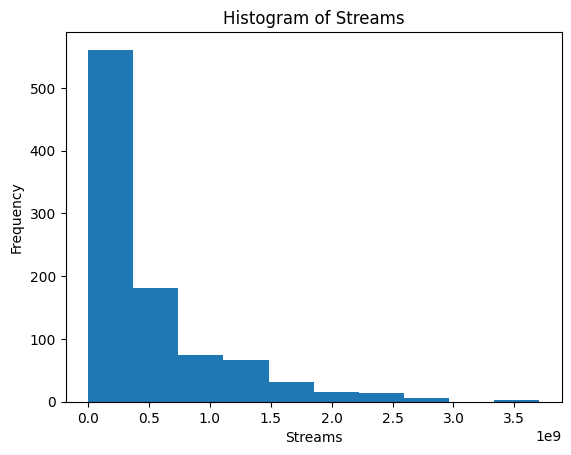

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
plt.hist(df['streams'], bins=10)
plt.xlabel("Streams")
plt.ylabel("Frequency")
plt.title("Histogram of Streams")
plt.show()

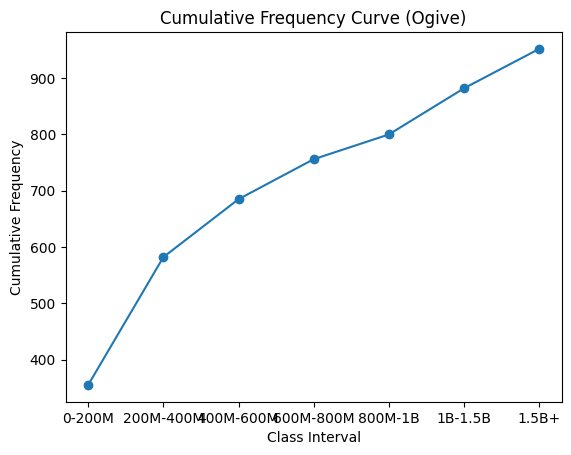

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("spotify-2023.csv", encoding='latin1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
bins = [0, 200000000, 400000000, 600000000, 800000000, 1000000000, 1500000000, df['streams'].max()]
labels = ['0-200M','200M-400M','400M-600M','600M-800M','800M-1B','1B-1.5B','1.5B+']
df['class'] = pd.cut(df['streams'], bins=bins, labels=labels)
freq = df['class'].value_counts().sort_index()
cum_freq = freq.cumsum()
plt.plot(labels, cum_freq, marker='o')
plt.xlabel("Class Interval")
plt.ylabel("Cumulative Frequency")
plt.title("Cumulative Frequency Curve (Ogive)")
plt.show()